In [2]:
import yt 
import numpy as np

def _gamma(field, data):
    u1 = data[('gas', 'four_velocity_r')]
    u2 = data[('gas', 'four_velocity_theta')]
    u3 = data[('gas', 'four_velocity_z')]
    c = data.ds.quan(1.0, 'code_velocity')
    return (1 + (u1/c)**2 + (u2/c)**2 + (u3/c)**2)**0.5


yt.add_field(('gas', 'lorentz_gamma'), function=_gamma, units="", sampling_type = "cell", dimensions = yt.units.dimensionless)
# Cartesian velocity components derived directly from the native cylindrical fields.
# ('athena_pp', 'vel1') = v_R,  ('athena_pp', 'vel2') = v_phi
# ('index', 'theta')    = azimuthal angle phi of each cell
# v_x = v_R*cos(phi) - v_phi*sin(phi)
# v_y = v_R*sin(phi) + v_phi*cos(phi)
def _vel_cyl_x(field, data):
    phi  = data[('index', 'theta')]
    vr   = data[('athena_pp', 'vel1')]
    vphi = data[('athena_pp', 'vel2')]
    return vr * np.cos(phi) - vphi * np.sin(phi)

def _vel_cyl_y(field, data):
    phi  = data[('index', 'theta')]
    vr   = data[('athena_pp', 'vel1')]
    vphi = data[('athena_pp', 'vel2')]
    return vr * np.sin(phi) + vphi * np.cos(phi)

yt.add_field(('gas', 'vel_cyl_x'), function=_vel_cyl_x,
             units='code_velocity', sampling_type='cell', force_override=True)
yt.add_field(('gas', 'vel_cyl_y'), function=_vel_cyl_y,
             units='code_velocity', sampling_type='cell', force_override=True)

In [3]:
def _enthalpy(field, data):
    rho = data[('athena_pp', 'rho')]
    P = data[('athena_pp', 'press')]
    c = data.ds.quan(1.0, 'code_velocity')
    return 1 + 4*P/(rho*c**2)


yt.add_field(('gas', 'enthalpy'), function=_enthalpy, units="", sampling_type="cell", dimensions=yt.units.dimensionless)

def _entropy(field, data):
    rho = data[('athena_pp', 'rho')]
    P = data[('athena_pp', 'press')]
    c = data.ds.quan(1.0, 'code_velocity')
    return P/rho**(4/3)

yt.add_field(('gas', 'entropy'), function=_entropy, units="code_length**3/(code_mass**(1/3)*code_time**2)", sampling_type="cell")

# LEnthalpy first

yt : [WARNING  ] 2026-05-18 14:05:35,934 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-05-18 14:05:35,935 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-05-18 14:05:35,935 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-05-18 14:05:35,936 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-05-18 14:05:35,957 Parameters: current_time              = 2.5
yt : [INFO     ] 2026-05-18 14:05:35,957 Parameters: domain_dimensions         = [1200  800    1]
yt : [INFO     ] 2026-05-18 14:05:35,958 Parameters: domain_left_edge          = [0.001 0.    0.   ]
yt : [INFO     ] 2026-05-18 14:05:35,958 Parameters: domain_right_edge         = [1.5        6.28318531 1.        ]
yt : [INFO     ] 2026-05-18 14:05:35,958 Parameters: cosmological_simulation   = 0


Shock fronts at theta=4.712 rad: 1.002 R_*
Shock fronts at theta=4.695 rad: 1.002 R_*
Shock fronts at theta=4.677 rad: 1.002 R_*
Shock fronts at theta=4.660 rad: 1.002 R_*
Shock fronts at theta=4.642 rad: 1.002 R_*
Shock fronts at theta=4.625 rad: 1.002 R_*
Shock fronts at theta=4.607 rad: 1.002, 1.023, 1.082 R_*
Shock fronts at theta=4.590 rad: 1.002, 1.121 R_*
Shock fronts at theta=4.572 rad: 1.002, 1.152 R_*
Shock fronts at theta=4.554 rad: 1.000, 1.120, 1.191 R_*
Shock fronts at theta=4.537 rad: 0.985, 1.107, 1.155, 1.215 R_*
Shock fronts at theta=4.519 rad: 0.960, 1.137, 1.183, 1.236 R_*
Shock fronts at theta=4.502 rad: 0.921, 1.165, 1.208, 1.256 R_*
Shock fronts at theta=4.484 rad: 1.201, 1.242, 1.283 R_*
Shock fronts at theta=4.467 rad: 1.223, 1.262, 1.301 R_*
Shock fronts at theta=4.449 rad: 1.245, 1.281, 1.318 R_*
Shock fronts at theta=4.432 rad: 1.263, 1.298, 1.333 R_*
Shock fronts at theta=4.414 rad: 1.282, 1.316, 1.348 R_*
Shock fronts at theta=4.396 rad: 1.307, 1.339, 1.37

/tmp/ipykernel_486448/3019596292.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


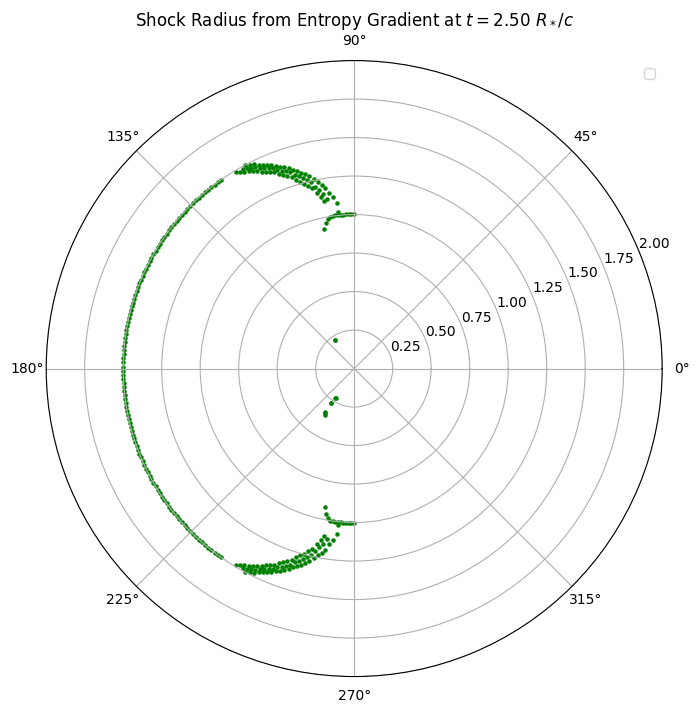

yt : [INFO     ] 2026-05-18 14:05:38,772 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-05-18 14:05:38,773 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-05-18 14:05:38,773 Setting origin='native' for cylindrical geometry.
yt : [INFO     ] 2026-05-18 14:05:38,776 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-05-18 14:05:38,776 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-05-18 14:05:38,776 Making a fixed resolution buffer of (('gas', 'entropy')) 800 by 800



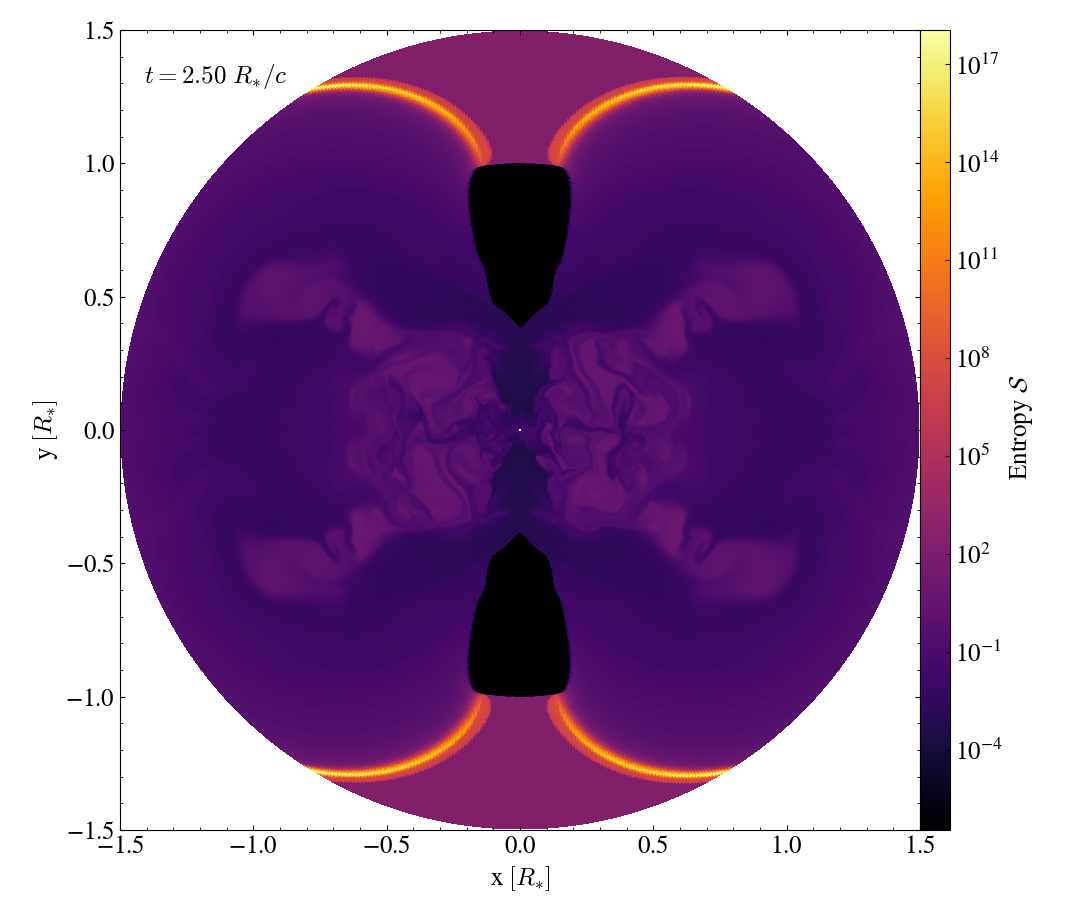

In [45]:

import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# 1D velocity profile at a fixed azimuthal angle
theta_vals = np.linspace(3*np.pi/2, np.pi/2, 180)  # example theta values
z_val     = 0.5   #doesnt matter

ds_entr = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.02500.athdf')


r_shock_entropy = []  # list of lists: 1 or more radii per theta

for theta_val in theta_vals:
    ray = ds_entr.ortho_ray(0, (theta_val, z_val))

    df_entr = ray.to_dataframe([('index', 'r'), ('gas', 'entropy')])
    df_entr = df_entr.sort_values('r').reset_index(drop=True)

    if len(df_entr) < 2:
        r_shock_entropy.append([np.nan])
        continue

    # Shock has hit the surface: outer boundary entropy is still unshocked
    if np.log10(df_entr['entropy'].iloc[-1]) < 1:
        r_shock_entropy.append([1.5])
        print(f"Shock at surface for theta={theta_val:.3f} rad")
        continue

    dlogS_dr = np.gradient(np.log10(df_entr['entropy']), df_entr['r'])
    abs_grad = np.abs(dlogS_dr)

    peaks, _ = find_peaks(abs_grad, height=100, distance=10)
    peak_radii = sorted(
        [float(df_entr['r'].iloc[i]) for i in peaks if df_entr['r'].iloc[i] > 0.2],
        reverse=True
    )

    max_distance = 0.3  # tune: max allowed distance from outermost shock front

    selected = []
    if peak_radii:
        r_outer = peak_radii[0]
        selected = [r for r in peak_radii if r_outer - r <= max_distance]

    # Separately keep stellar surface peak near R=1.0
    surface_peaks = [r for r in peak_radii if 0.85 < r < 1.15]
    if surface_peaks and (not selected or min(abs(s - 1.0) for s in selected) > 0.1):
        selected.append(min(surface_peaks, key=lambda r: abs(r - 1.0)))

    radii = sorted(selected)
    if radii:
        print(f"Shock fronts at theta={theta_val:.3f} rad: {', '.join(f'{r:.3f}' for r in radii)} R_*")
        r_shock_entropy.append(radii)
    else:
        r_shock_entropy.append([np.nan])
    # fig, ax = plt.subplots()
    # ax.plot(df_entr['r'], df_entr['entropy'], label='Entropy')
    # ax.plot(df_entr['r'], abs_grad, label='|dlogS/dr|', alpha=0.5)
    # for r in radii:
    #     ax.axvline(r, color='r', linestyle='--', label=f'shock r={r:.3f}')
    # ax.set_xlabel(r"$r \ [R_*]$")
    # ax.set_ylabel(r"Entropy $\mathcal{S}$")
    # ax.set_title(rf"Entropy at $\theta = {theta_val*180/np.pi:.3f}$°, $t = {float(ds_entr.current_time):.2f}\ R_*/c$") 
    # ax.legend()
    # plt.show()

# Flatten for polar plot: duplicate theta for entries with two fronts
plot_theta = [th for th, rs in zip(theta_vals, r_shock_entropy) for _ in rs]
plot_r     = [r  for rs in r_shock_entropy for r in rs]

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(12, 8))
ax.scatter(plot_theta, plot_r, marker='o', color='g', s=5)
ax.set_rlim(0, 2)
ax.set_title(rf"Shock Radius from Entropy Gradient at $t = {float(ds_entr.current_time):.2f}\ R_*/c$")
ax.legend()
plt.show()

p = yt.SlicePlot(ds_entr, 'z', ('gas', 'entropy'))
p.annotate_timestamp(corner="upper_left", text_args={"color": "black"}, time_format=r"$t = {time:.2f}\ R_{{*}}/c$")
p.set_cmap(("gas", "entropy"), "inferno")
p.set_xlabel(r"x $[R_{*}]$")
p.set_ylabel(r"y $[R_{*}]$")
p.set_colorbar_label(("gas", "entropy"), r" Entropy $\mathcal{S}$")

# Lorentz Factor tracking

yt : [WARNING  ] 2026-05-18 13:48:12,102 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-05-18 13:48:12,103 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-05-18 13:48:12,103 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-05-18 13:48:12,103 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-05-18 13:48:12,125 Parameters: current_time              = 2.1000031054510493
yt : [INFO     ] 2026-05-18 13:48:12,125 Parameters: domain_dimensions         = [1200  800    1]
yt : [INFO     ] 2026-05-18 13:48:12,125 Parameters: domain_left_edge          = [0.001 0.    0.   ]
yt : [INFO     ] 2026-05-18 13:48:12,126 Parameters: domain_right_edge         = [1.5        6.28318531 1.        ]
yt : [INFO     ] 2026-05-18 13:48:12,126 Parameters: cosmological_simulation   = 0


Shock fronts at theta=0.000 rad: 1.223, 1.237, 1.251 R_*
Shock fronts at theta=0.035 rad: 1.222, 1.247 R_*
Shock fronts at theta=0.070 rad: 1.222, 1.238 R_*
Shock fronts at theta=0.105 rad: 1.221, 1.237 R_*
Shock fronts at theta=0.140 rad: 1.217, 1.233 R_*
Shock fronts at theta=0.176 rad: 1.225 R_*
Shock fronts at theta=0.211 rad: 1.216, 1.236 R_*
Shock fronts at theta=0.246 rad: 0.298, 1.220, 1.237 R_*
Shock fronts at theta=0.281 rad: 0.296, 1.230, 1.246 R_*
Shock fronts at theta=0.316 rad: 0.293, 1.240, 1.255 R_*
Shock fronts at theta=0.351 rad: 0.290, 1.246, 1.262 R_*
Shock fronts at theta=0.386 rad: 0.288, 1.252, 1.268 R_*
Shock fronts at theta=0.421 rad: 0.285, 1.255, 1.271 R_*
Shock fronts at theta=0.456 rad: 0.283, 1.257, 1.273 R_*
Shock fronts at theta=0.491 rad: 0.281, 1.257, 1.273 R_*
Shock fronts at theta=0.527 rad: 0.281, 1.255, 1.272 R_*
Shock fronts at theta=0.562 rad: 1.252, 1.268 R_*
Shock fronts at theta=0.597 rad: 1.248, 1.263 R_*
Shock fronts at theta=0.632 rad: 1.24

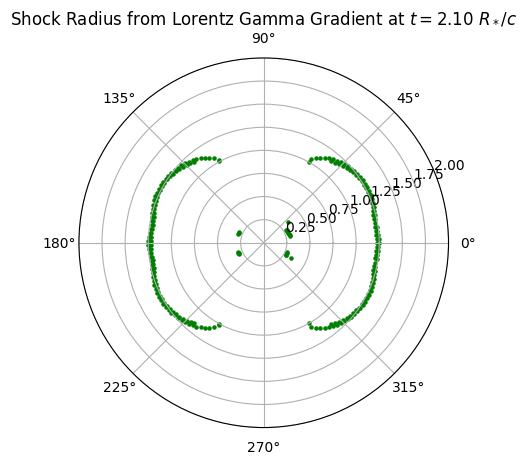

yt : [INFO     ] 2026-05-18 13:48:15,132 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-05-18 13:48:15,132 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-05-18 13:48:15,133 Setting origin='native' for cylindrical geometry.
yt : [INFO     ] 2026-05-18 13:48:15,134 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-05-18 13:48:15,134 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-05-18 13:48:15,135 Making a fixed resolution buffer of (('gas', 'lorentz_gamma')) 800 by 800



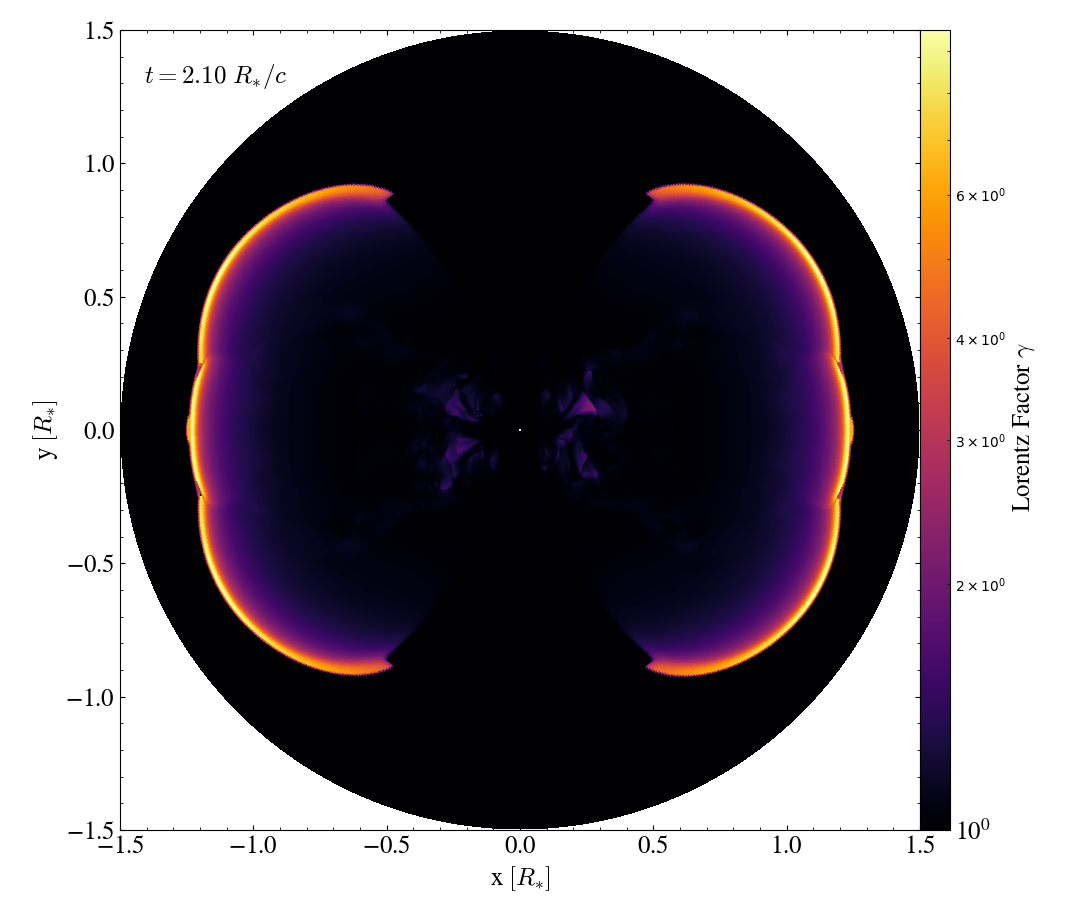

In [28]:
ds_gamma = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.02100.athdf')

theta_vals = np.linspace(0, 2*np.pi, 180)  # example theta values

radii_gamma = []  # one entry per theta_val: list of radii or [nan]


for theta_val in theta_vals:
    ray = ds_gamma.ortho_ray(0, (theta_val, z_val))
    df_gamma = ray.to_dataframe([('index', 'r'), ('gas', 'lorentz_gamma')])
    df_gamma = df_gamma.sort_values('r').reset_index(drop=True)

    if len(df_gamma) < 2:
        radii_gamma.append([np.nan])  # was: bare continue (bug 1)
        continue

    dgamma_dr = np.gradient(df_gamma['lorentz_gamma'], df_gamma['r'])
    abs_grad = np.abs(dgamma_dr)

    peaks, _ = find_peaks(abs_grad, height=100, distance=10)
    radii = [float(df_gamma['r'].iloc[i]) for i in peaks if df_gamma['r'].iloc[i] > 0.2]

    if radii:
        print(f"Shock fronts at theta={theta_val:.3f} rad: {', '.join(f'{r:.3f}' for r in radii)} R_*")
        radii_gamma.append(radii)
    else:
        radii_gamma.append([np.nan])  # was: nothing (bug 2)

    # fig, ax = plt.subplots()
    # ax.plot(df_gamma['r'], df_gamma['lorentz_gamma'], label='Lorentz Gamma')
    # ax.plot(df_gamma['r'], dgamma_dr, label='dGamma/dr', alpha=0.5)
    # for r in radii:
    #     ax.axvline(r, color='r', linestyle='--', label=f'shock r={r:.3f}')
    # ax.set_xlabel(r"$r \ [R_*]$")
    # ax.set_ylabel(r"Lorentz Factor $\gamma$")
    # ax.set_title(rf"Lorentz Factor at $\theta = {theta_val*180/np.pi:.3f}$°, $t = {float(ds_gamma.current_time):.2f}\ R_*/c$")
    # ax.legend()
    # plt.show()

# Flatten using zip so theta tracks actual detection angles (bug 3 fix)
plot_theta = [th for th, rs in zip(theta_vals, radii_gamma) for _ in rs]
plot_r     = [r  for rs in radii_gamma for r in rs]

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.scatter(plot_theta, plot_r, marker='o', color='g', s=5)
ax.set_rlim(0, 2)
ax.set_title(rf"Shock Radius from Lorentz Gamma Gradient at $t = {float(ds_gamma.current_time):.2f}\ R_*/c$")
plt.show()

p = yt.SlicePlot(ds_gamma, 'z', ('gas', 'lorentz_gamma'))
p.annotate_timestamp(corner="upper_left", text_args={"color": "black"}, time_format=r"$t = {time:.2f}\ R_{{*}}/c$")
p.set_cmap(("gas", "lorentz_gamma"), "inferno")
p.set_xlabel(r"x $[R_{*}]$")
p.set_ylabel(r"y $[R_{*}]$")
p.set_colorbar_label(("gas", "lorentz_gamma"), r" Lorentz Factor $\gamma$")


## Video of the whole thing

In [ ]:
from pathlib import Path
ts = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.*.athdf')
nx, ny = ts[0].domain_dimensions[0], ts[0].domain_dimensions[1]
frames_dir = Path('/scratch/aripoll/athena_out/frames')
frames_dir.mkdir(parents=True, exist_ok=True)

for i, ds in enumerate(ts[800:1100], start=800):
    r_shock_entropy = []  # list of lists: 1 or more radii per theta

    for theta_val in theta_vals:
        ray = ds.ortho_ray(0, (theta_val, z_val))

        df_entr = ray.to_dataframe([('index', 'r'), ('gas', 'entropy')])
        df_entr = df_entr.sort_values('r').reset_index(drop=True)

        if len(df_entr) < 2:
            r_shock_entropy.append([np.nan])
            continue

        # Shock has hit the surface: outer boundary entropy is still unshocked
        if np.log10(df_entr['entropy'].iloc[-1]) < 5:
            r_shock_entropy.append([1.5])
            # print(f"Shock at surface for theta={theta_val:.3f} rad")
            continue

        dlogS_dr = np.gradient(np.log10(df_entr['entropy']), df_entr['r'])
        abs_grad = np.abs(dlogS_dr)

        peaks, _ = find_peaks(abs_grad, height= 100, distance = 10)
        radii = [float(df_entr['r'].iloc[i]) for i in peaks if df_entr['r'].iloc[i] > 0.2]

        if radii:
            # print(f"Shock fronts at theta={theta_val:.3f} rad: {', '.join(f'{r:.3f}' for r in radii)} R_*")
            r_shock_entropy.append(radii)
        else:
            r_shock_entropy.append([np.nan])
        # fig, ax = plt.subplots()
        # ax.plot(df_entr['r'], abs_grad, label='Entropy')
        # for r in radii:
        #     ax.axvline(r, color='r', linestyle='--', label=f'shock r={r:.3f}')
        # ax.set_xlabel(r"$r \ [R_*]$")
        # ax.set_ylabel(r"Entropy $\mathcal{S}$")
        # ax.set_title(rf"Entropy at $\theta = {theta_val*180/np.pi:.3f}$°, $t = {float(ds.current_time):.2f}\ R_*/c$") 
        # ax.legend()
        # plt.show()

    # Flatten for polar plot: duplicate theta for entries with two fronts
    plot_theta = [th for th, rs in zip(theta_vals, r_shock_entropy) for _ in rs]
    plot_r     = [r  for rs in r_shock_entropy for r in rs]

    plt.figure(figsize=(20, 20))
    plt.polar(plot_theta, plot_r, marker='o', color='g', linestyle='none')
    plt.title(rf"Shock Radius from Entropy Gradient at $t = {float(ds.current_time):.2f}\ R_*/c$")
    plt.savefig(frames_dir / f"frame_{i:04d}.png", dpi=100, bbox_inches='tight')
    plt.close()

In [ ]:
#Now make a video using ffmpeg starting from the first frame frame_1400.png to frame_1499.png
frames_dir = Path('/scratch/aripoll/athena_out/frames')
frames_dir.mkdir(parents=True, exist_ok=True)
import subprocess
subprocess.run(['ffmpeg', '-y', '-framerate', '10', '-start_number', '800', '-i', str(frames_dir / 'frame_%04d.png'), '-c:v', 'libx264', '-pix_fmt', 'yuv420p', '-vf', 'pad=ceil(iw/2)*2:ceil(ih/2)*2', 'shock_evolution.mp4'], check=True)

from IPython.display import Video, display
display(Video('shock_evolution.mp4', embed=True))

### Velocity of points

In [ ]:
from pathlib import Path
ts = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.*.athdf')
nx, ny = ts[0].domain_dimensions[0], ts[0].domain_dimensions[1]
frames_dir = Path('/scratch/aripoll/athena_out/frames')
frames_dir.mkdir(parents=True, exist_ok=True)

# Store the list of radii so we can get a velocity
shock_records = []  # list of tuples: (time, list of lists of shock radii per theta)
for i, ds in enumerate(ts[:1100], start=0):
    r_shock = []  # list of lists: 1 or more radii per theta
    for theta_val in theta_vals:
        ray = ds.ortho_ray(0, (theta_val, z_val))

        df_entr = ray.to_dataframe([('index', 'r'), ('gas', 'entropy')])
        df_entr = df_entr.sort_values('r').reset_index(drop=True)

        if len(df_entr) < 2:
            r_shock.append([np.nan])
            continue

        # Shock has hit the surface: outer boundary entropy is still unshocked
        if np.log10(df_entr['entropy'].iloc[-1]) < 5:
            r_shock.append([1.5])
            print(f"Shock at surface for theta={theta_val:.3f} rad")
            continue

        dlogS_dr = np.gradient(np.log10(df_entr['entropy']), df_entr['r'])
        abs_grad = np.abs(dlogS_dr)

        peaks, _ = find_peaks(abs_grad, height=100, distance=10)
        radii = [float(df_entr['r'].iloc[p]) for p in peaks if df_entr['r'].iloc[p] > 0.2]

        if radii:
            print(f"Shock fronts at theta={theta_val:.3f} rad: {', '.join(f'{r:.3f}' for r in radii)} R_*")
            r_shock.append(radii)
        else:
            r_shock.append([np.nan])
    shock_records.append((float(ds.current_time), r_shock))

print(f"Collected {len(shock_records)} timesteps")

velocities = []  # list of (theta, r_mid, v_shock)
for i in range(1, len(shock_records)):
    t0, shock0 = shock_records[i - 1]
    t1, shock1 = shock_records[i]
    dt = t1 - t0

    for theta_val, rs0, rs1 in zip(theta_vals, shock0, shock1):
        if np.isnan(rs0).all() or np.isnan(rs1).all():
            continue  # skip if either timestep has no shock front

        valid0 = sorted(r for r in rs0 if not np.isnan(r))
        valid1 = sorted(r for r in rs1 if not np.isnan(r))
        used = set()
        for r0 in valid0:
            dists = [(abs(r0 - r1), j, r1) for j, r1 in enumerate(valid1) if j not in used]
            if not dists:
                continue
            _, j, r1 = min(dists)
            used.add(j)
            velocities.append((theta_val, (r0 + r1) / 2, (r1 - r0) / dt))

print(f"Computed {len(velocities)} velocity measurements")

In [ ]:
thetas = np.array([v[0] for v in velocities])
radii  = np.array([v[1] for v in velocities])
vels   = np.array([v[2] for v in velocities])

vmax = np.nanpercentile(np.abs(vels), 95)

# Polar scatter: shock speed at each (theta, r) position
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'})
sc = ax.scatter(thetas, radii, c=vels, cmap='RdBu_r', s=5, vmin=-vmax, vmax=vmax)
plt.colorbar(sc, ax=ax, label=r'$v_{\rm shock}\ [c]$', fraction=0.04)
ax.set_title(r"Shock Velocity $dr/dt$ [c]" + f"\n({len(shock_records)} timesteps)")
plt.tight_layout()
plt.show()

# Velocity vs. radius at theta = 0
theta0 = theta_vals[0]
mask = thetas == theta0
r0_arr = radii[mask]
v0_arr = vels[mask]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(r0_arr, v0_arr, s=10, c='steelblue', alpha=0.7)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel(r"$r\ [R_*]$")
ax.set_ylabel(r"$v_{\rm shock}\ [c]$")
ax.set_title(r"Shock Velocity vs. Radius at $\theta = 0$")
plt.tight_layout()
plt.show()